# Exploratory Data Analysis - NinaPro

In [6]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
from src.utils import load_emg_data
from src.visualization import plot_signal_head

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Basic Configuration

In [7]:
DATABASE = 'DB5'
SUBJECT = 1
ZIP_PATH = f'../data/raw/Ninapro_{DATABASE}/s{SUBJECT}.zip'

print(f"Exploring {DATABASE} Subject {SUBJECT}...")

Exploring DB5 Subject 1...


## 2. Data Loading

In [8]:
df_emg, stimulus, restimulus, repetition = load_emg_data(ZIP_PATH)

print(f"EMG shape: {df_emg.shape} (n_samples × n_channels)")
print(f"Stimulus unique values: {sorted(np.unique(stimulus))}")
print(f"Restimulus unique values: {sorted(np.unique(restimulus))}")
print(f"Repetition unique values: {sorted(np.unique(repetition))}")
print(f"Number of gestures: {len(np.unique(restimulus)) - 1} + rest")

EMG shape: (568540, 16) (n_samples × n_channels)
Stimulus unique values: [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7), np.int8(8), np.int8(9), np.int8(10), np.int8(11), np.int8(12), np.int8(13), np.int8(14), np.int8(15), np.int8(16), np.int8(17), np.int8(18), np.int8(19), np.int8(20), np.int8(21), np.int8(22), np.int8(23)]
Restimulus unique values: [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7), np.int8(8), np.int8(9), np.int8(10), np.int8(11), np.int8(12), np.int8(13), np.int8(14), np.int8(15), np.int8(16), np.int8(17), np.int8(18), np.int8(19), np.int8(20), np.int8(21), np.int8(22), np.int8(23)]
Repetition unique values: [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5), np.int8(6)]
Number of gestures: 23 + rest


## 3. Check sampling rate and recording duration

In [9]:
fs = 200  # DB5: 200 Hz
duration_seconds = df_emg.shape[0] / fs
print(f"Sampling rate: {fs} Hz")
print(f"Recording duration: {duration_seconds:.1f} seconds ({duration_seconds/60:.1f} minutes)")

Sampling rate: 200 Hz
Recording duration: 2842.7 seconds (47.4 minutes)


## 4. Raw Signal Visualization

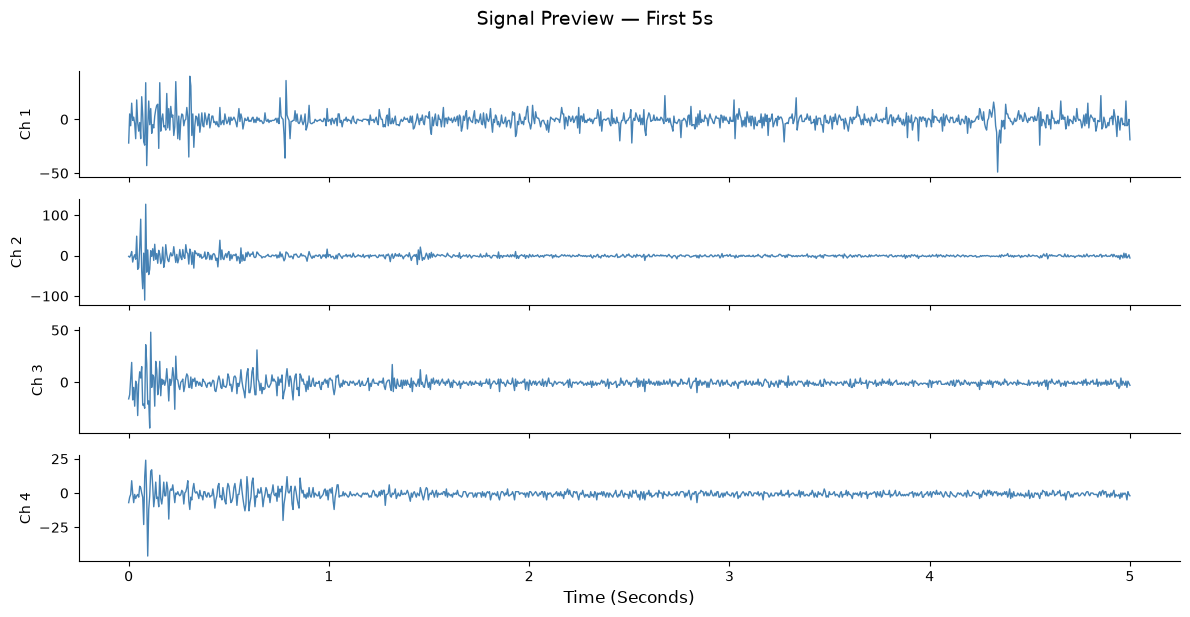

In [10]:
fig = plot_signal_head(df_emg, labels=restimulus, n_seconds=5, 
                       sampling_rate=fs, n_channels_to_show=4)
plt.show()

## 5. Check gesture distribution across repetitions

In [11]:
print("Windows per repetition (approximate):")
for r in sorted(np.unique(repetition)):
    count = np.sum(repetition == r)
    active_count = np.sum((repetition == r) & (restimulus > 0))
    print(f"  Rep {int(r)}: {count} total samples, {active_count} active gesture samples")

Windows per repetition (approximate):
  Rep 0: 219439 total samples, 219 active gesture samples
  Rep 1: 58395 total samples, 38980 active gesture samples
  Rep 2: 58152 total samples, 38281 active gesture samples
  Rep 3: 58116 total samples, 38986 active gesture samples
  Rep 4: 58169 total samples, 39865 active gesture samples
  Rep 5: 58148 total samples, 38982 active gesture samples
  Rep 6: 58121 total samples, 38591 active gesture samples
